In [1]:
import wandb

import pandas as pd

from tqdm import tqdm

from matplotlib import pyplot as plt

import numpy as np 

from xaikd import models, datasets

from torch.utils.data import DataLoader
from xaikd.utils import metrics

from contextlib import nullcontext

from datetime import datetime

In [2]:
api = wandb.Api()

In [3]:
EXPERIMENT_GROUP = "./artifacts/2023-10-s17/experiments/ex3.0-distill-under-data-scarcity-sgd--hyperopt-clean"

In [23]:
def read_data(
    teacher,
    student,
    dataset,
    policy,
    lambda_task,
    lambda_kd,
    training_size,
    use_val_split,
    contamination_level,
    verbose=False,
    
):
    
    assert use_val_split

    
    runs = api.runs(
        f'p16i/xaikd-distillation-layerwise-ep3',
        {
        "$and": [
            {"group": EXPERIMENT_GROUP},
            {"config.teacher": teacher},
            {"config.dataset": dataset},
            {"config.student": student},
            {"config.lambda_task": lambda_task},
            {"config.lambda_kd": lambda_kd},
            {"config.policy": policy},
            {"config.training_size": training_size},
            {"config.contamination_level": contamination_level},
            {"config.use_val_split": use_val_split},
        ]}
    )
    
    if verbose:
        print(f"we have {len(runs)} runs")
    
    rows = []
    
    count = 0
    
    datasets = []
    for run in runs:
        seed = run.config["seed"]
        
        if not "arr_metrics"in run.summary:
            if verbose:

                print(">> bad run config")
                print(run.config)
            
            count += 1
            continue
                     
        k = np.argmax(run.summary["arr_metrics"]["val_acc"])
        datasets.append(run.config["dataset"])
        best_val_acc = run.summary["arr_metrics"]["val_acc"][k]
        
        rows.append(
            dict(
                best_epoch=k,
                seed=seed, 
                lambda_task=run.config["lambda_task"],
                lambda_kd=run.config["lambda_kd"],
                # remark: this is the actual value used in distillation
                # cf. https://github.com/p16i/xai-kd/blob/2023-09-s14--1-teacher-training-script/scripts/distill-layerwise.py#L364
                lambda_layer=run.config["policy_lambda_layer"],
                val_acc=best_val_acc, 
#                 val_agreement=best_val_agreement,
#                 val_agreement_on_teacher_correct=best_val_agreement_on_teacher_correct,
                teacher_acc=run.summary["teacher_acc"],
                policy=run.config["policy"]
            )
        )

    if count != 0:
        print(f"We have {count} bad run! abort!")
#         raise
    
    df = pd.DataFrame(rows)
        
        
    df = df.groupby(by="lambda_layer").agg(
        {
            "val_acc": ["mean", "std", "count"],
            "teacher_acc": ["mean"]
        }
    ).reset_index()
    
#     np.testing.assert_allclose(
#         df["val_acc"]["count"].values,
#         3
#     )
    
    if verbose:
        print(f"df.shape: {df.shape}")
    return df

summary = read_data(
    dataset="cifar100-people",
    teacher="cifar100-resnet18-v1",
    student="resnet18xscifarcompr1",
    lambda_task=0.0,
    lambda_kd=1.0,
#     policy="basis-identity:random--uncentered",
    policy="vid",
    training_size=1.0,
    verbose=True,
    contamination_level=0.0,
    use_val_split=True
)

summary

we have 27 runs
df.shape: (9, 5)


lambda_layer   val_acc                 teacher_acc
                    mean       std count        mean
0        0.000  0.476286  0.026687     3    0.998664
1        0.001  0.486306  0.012080     3    0.998664
2        0.010  0.482298  0.015041     3    0.998664
3        0.100  0.470274  0.019257     3    0.998664
4        1.000  0.478290  0.009471     3    0.998664
5       10.000  0.587842  0.003061     3    0.998664
6      100.000  0.225117  0.011570     3    0.998664
7     1000.000  0.211089  0.007587     3    0.998664
8    10000.000  0.211089  0.007587     3    0.998664

# Comparison on `cifar100-resnet18-v1`

student: resnet18xscifarcompr1
experiment group: ./artifacts/2023-10-s17/experiments/ex3.0-distill-under-data-scarcity-sgd--hyperopt-clean
date: 2023-10-26 20:12:51.223462
[contamination-level=0.0]> Best Lambda for `          basis-identity:pca--uncentered`: 0.0010
[contamination-level=0.0]> Best Lambda for ` basis-identity:prca-sortabs--uncentered`: 0.0010
[contamination-level=0.0]> Best Lambda for `       basis-identity:random--uncentered`: 0.0010
We have 1 bad run! abort!
[warning] policy=vid: [3 3 3 3 2 3 3 3 3]
[contamination-level=0.0]> Best Lambda for `                                     vid`: 0.0010
We have 2 bad run! abort!
[warning] policy=attention-transfer: [3 3 3 3 1 3 3 3 3]
[contamination-level=0.0]> Best Lambda for `                      attention-transfer`: 1000.0000
We have 1 bad run! abort!
[warning] policy=fitnet: [3 3 3 3 2 3 3 3 3]
[contamination-level=0.0]> Best Lambda for `                                  fitnet`: 0.0010


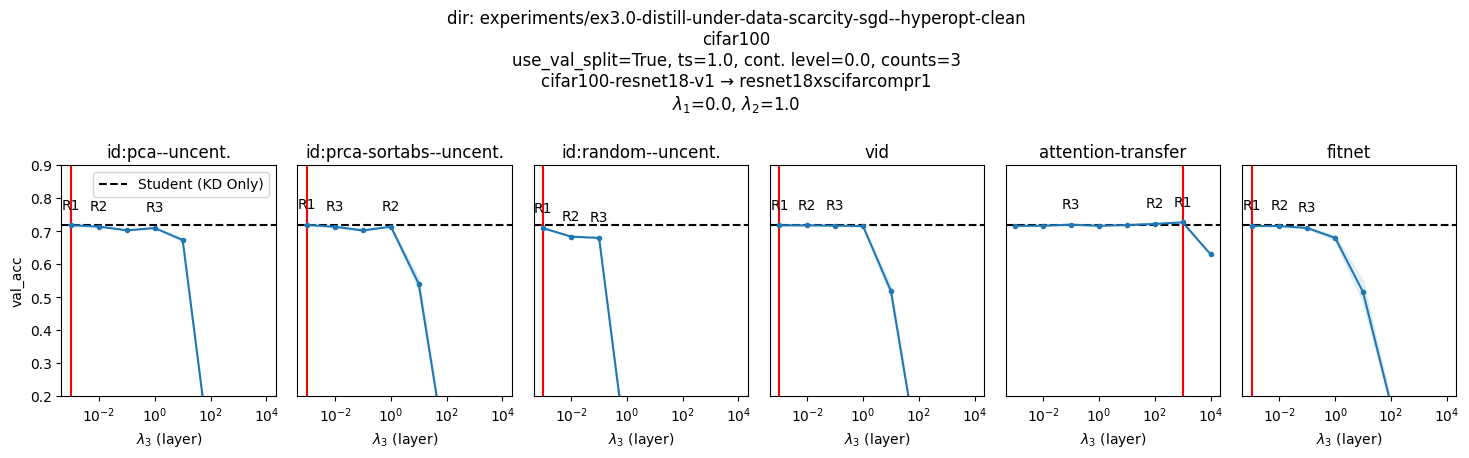

In [28]:
def ls(policy):
    if policy in ["fitnet", "attention-transfer", "vid"] :
        return ":"
    elif policy == "fitnetinvidbnrelu":
        return "-."
    else:
        return "-"
    
def marker(policy):
    return "."
    
    if "inner" in policy:
        return "."
    else:
        return None

def alias(policy):
    
    return policy \
        .replace("basis-identity", "id") \
        .replace("uncentered", "uncent.")

    
def viz_distillation(
    dataset,
    teacher, student, policies,
    show_legend=True,
    contamination_level=0.0
):
        

    training_size = 1.0
    use_val_split = True
    lambda_kd = 1.0
    lambda_task = 0.0
            
    col = "val_acc"
    
    ncols = 6
    nrows = 1
    
    plt.figure(figsize=(3*ncols, 3*nrows))
    
    dirslug = "/".join(f"{EXPERIMENT_GROUP}".split("/")[-2:])

    count = None
    
    print("============")
    print(f"student: {student}")
    print(f"experiment group: {EXPERIMENT_GROUP}")
    print(f"date: {datetime.now()}")
    for pix, policy in enumerate(policies):
        plt.subplot(nrows, ncols, pix+1)
        plt.title(alias(policy))

        df = read_data(
            dataset=dataset,
            teacher=teacher,
            student=student,
            policy=policy,
            lambda_task=lambda_task,
            lambda_kd=lambda_kd,
            training_size=training_size,
            contamination_level=contamination_level,
            use_val_split=use_val_split,
            verbose=False
        )
        
        
        with nullcontext(enter_result="sanity check"):            
            if count == None:

#                 np.testing.assert_equal(
#                     df[col]["count"].values,
#                     df[col]["count"].values[0]
#                 )

                count = df[col]["count"].values[0]
            else:
#                 np.testing.assert_equal(df[col]["count"].values, count)  
                pass 

            if not (df[col]["count"].values == df[col]["count"].values[0]).all() \
                or df[col]["count"].values[0] != count:
                    print(f"[warning] policy={policy}:", df[col]["count"].values)    
        
    
        
        if pix > 0:
            try:
                pass
#                 np.testing.assert_allclose(
#                     acc_student_kd_only,
#                     df[col]["mean"].values[0],
#                     atol=1e-2
#                 )
            except Exception as err:
                print(f"[policy={policy}] acc does not match!")
                print(err)
        else:
            acc_student_kd_only = df[col]["mean"].values[0]
        
        plt.axhline(
            acc_student_kd_only,
            ls="--",
            color="k",
            label="Student (KD Only)"
        )
        
        
        # here, we use [1:] to excluding lambda_layer=0
        assert df["lambda_layer"][0] == 0.0
        ticks = df["lambda_layer"][1:]
        mean = df[col]["mean"][1:]
        stderr = df[col]["std"][1:] / (count ** 0.5)
        
        best_k = np.argmax(df[col]["mean"])
        best_lambda_layer = df["lambda_layer"][best_k]
        
        sorted_indices = np.argsort(-mean.values)
        
        for _i in range(3):
            rix = sorted_indices[_i]
   
            plt.annotate(
                f"R{_i+1}",
                (ticks.values[rix], mean.values[rix] + 0.05), 
                ha="center",
            )
             
            if _i == 0:
                plt.axvline(ticks.values[rix], ls="-", color="r")
                print(f"[contamination-level={contamination_level}]> Best Lambda for `{policy:>40s}`: {ticks.values[rix]:.4f}")

        

        plt.plot(
            ticks,
            mean,
            marker="."
        )
        
        plt.fill_between(
            ticks,
            mean - stderr,
            mean + stderr,
            alpha=0.1,
            color=plt.gca().lines[-1].get_color()
        )
        

        plt.ylim([0.2, 0.9])
        plt.xscale("log")
        plt.xlabel("$\lambda_3$ (layer)")
        plt.ylabel(col)
        if pix == 0:
            plt.legend()
            
        if pix % ncols != 0:
            plt.ylabel("")
            plt.yticks([])
            
#         if pix // ncols in [3, 2]:
#             plt.xlabel("")
    
    plt.suptitle(
        "\n".join([
            f"dir: {dirslug}",
            dataset,
            f"use_val_split={use_val_split}, ts={training_size}, cont. level={contamination_level}, counts={count}",
            f"{teacher} → {student}",
            f"$\lambda_1$={lambda_task}, $\lambda_2$={lambda_kd}",
            "",
        ]),
        y=1.4,
    )
    
    plt.subplots_adjust(hspace=0.5, wspace=0.1)


viz_distillation(
    dataset="cifar100",
    teacher = "cifar100-resnet18-v1",
    student="resnet18xscifarcompr1",
    policies = [ 
        f"basis-identity:pca--uncentered",
        f"basis-identity:prca-sortabs--uncentered",
        f"basis-identity:random--uncentered",
        "vid",
        "attention-transfer",
        "fitnet",
    ],
)

student: resnet18xscifarcompr1
experiment group: ./artifacts/2023-10-s17/experiments/ex3.0-distill-under-data-scarcity-sgd--hyperopt-clean
date: 2023-10-26 20:12:55.712611
[contamination-level=0.0]> Best Lambda for `          basis-identity:pca--uncentered`: 0.0010
[contamination-level=0.0]> Best Lambda for ` basis-identity:prca-sortabs--uncentered`: 0.0010
[contamination-level=0.0]> Best Lambda for `       basis-identity:random--uncentered`: 0.0010
We have 1 bad run! abort!
[warning] policy=vid: [3 3 3 3 2 3 3 3 3]
[contamination-level=0.0]> Best Lambda for `                                     vid`: 0.0010
We have 2 bad run! abort!
[warning] policy=attention-transfer: [3 3 3 3 1 3 3 3 3]
[contamination-level=0.0]> Best Lambda for `                      attention-transfer`: 1000.0000
We have 1 bad run! abort!
[warning] policy=fitnet: [3 3 3 3 2 3 3 3 3]
[contamination-level=0.0]> Best Lambda for `                                  fitnet`: 0.0010


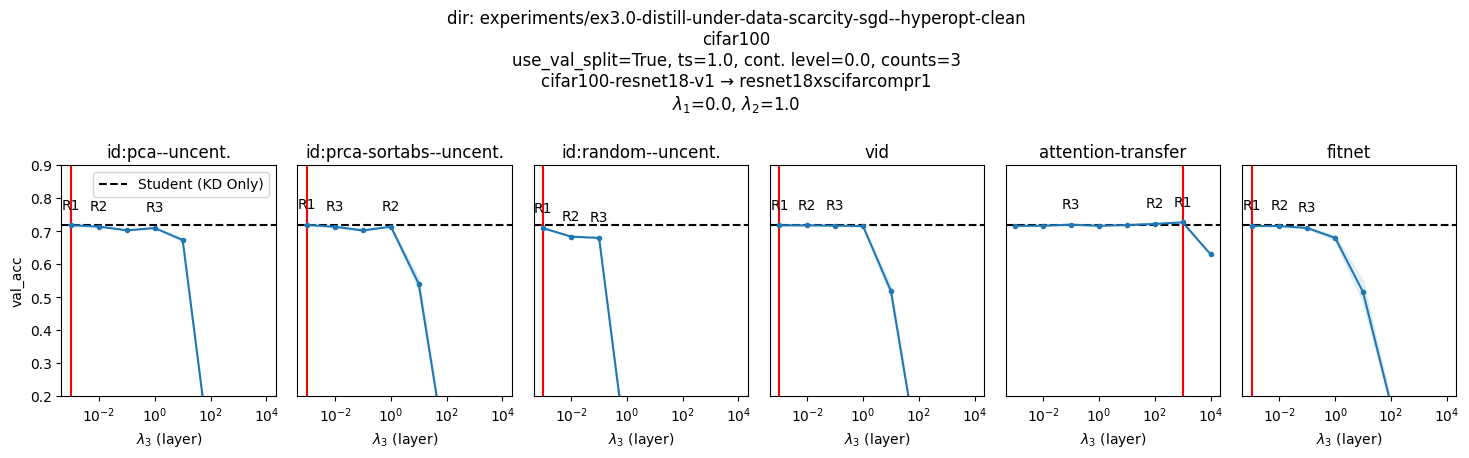

In [29]:

viz_distillation(
    dataset="cifar100",
    teacher = "cifar100-resnet18-v1",
    student="resnet18xscifarcompr1",
    policies = [ 
        f"basis-identity:pca--uncentered",
        f"basis-identity:prca-sortabs--uncentered",
        f"basis-identity:random--uncentered",
        "vid",
        "attention-transfer",
        "fitnet",
    ],
)

student: resnet18xscifarcompr4
experiment group: ./artifacts/2023-10-s17/experiments/ex3.0-distill-under-data-scarcity-sgd--hyperopt-clean
date: 2023-10-26 20:13:12.282957
[contamination-level=0.0]> Best Lambda for `          basis-identity:pca--uncentered`: 0.0010
[contamination-level=0.0]> Best Lambda for ` basis-identity:prca-sortabs--uncentered`: 0.0010
[contamination-level=0.0]> Best Lambda for `       basis-identity:random--uncentered`: 0.0010
We have 1 bad run! abort!
[warning] policy=vid: [3 3 3 3 2 3 3 3 3]
[contamination-level=0.0]> Best Lambda for `                                     vid`: 0.0010
We have 1 bad run! abort!
[warning] policy=attention-transfer: [3 3 3 3 2 3 3 3 3]
[contamination-level=0.0]> Best Lambda for `                      attention-transfer`: 0.0010
We have 1 bad run! abort!
[warning] policy=fitnet: [3 3 3 3 3 3 3 3 2]
[contamination-level=0.0]> Best Lambda for `                                  fitnet`: 0.0010


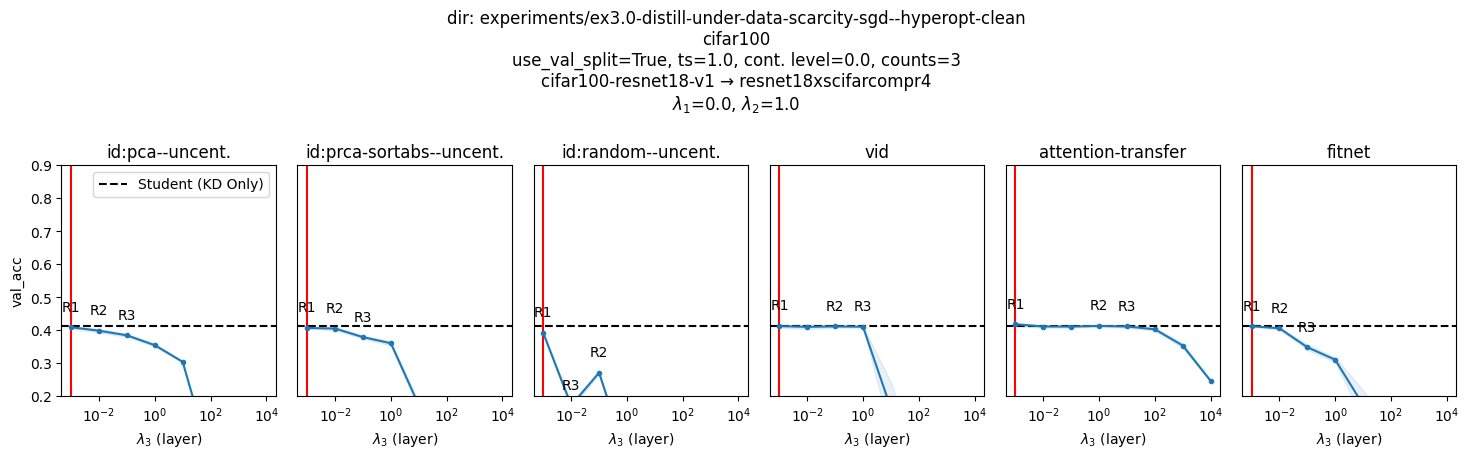

In [30]:
viz_distillation(
    dataset="cifar100",
    teacher = "cifar100-resnet18-v1",
    student="resnet18xscifarcompr4",
    policies = [ 
        f"basis-identity:pca--uncentered",
        f"basis-identity:prca-sortabs--uncentered",
        f"basis-identity:random--uncentered",
        "vid",
        "attention-transfer",
        "fitnet",
    ],
)

In [19]:
# for student in [
#     "resnet18xscifarcompr1",
#     "resnet18xscifarcompr2",
#     "resnet18xscifarcompr4"
# ]:

#     viz_distillation(
#         teacher = "cifar100-resnet18-v1",
#         student=student,
#         policies = [ 
#             f"basis-identity:pca--uncentered",
#             f"basis-identity:prca-sortabs--uncentered",
#             f"basis-identity:random--uncentered",
#             "vid",
#             "attention-transfer",
#             "fitnet",
#         ],
#     )

# Summary

<!-- Setup:
$$
 (0.0) \ell_\text{task} + \lambda_2 \ell_\text{KD} + \lambda_3 \ell_\text{layer},
$$
$\lambda_2 = 1$ and $\lambda_3 = \{0, 10^{-3}, 10^{-2}, \dots,  10^6\}$

*Aims:* 
- find optimal value for these policies

*Conclusion:*
- the range of good values of $\lambda_3$ is more or less similar across the three student models.
- `attention-transfer` is more sensitive to the value of $\lambda_3$ than others.
- `fitnet` seems to underperform (worse than `Student (KD Only)`) in the prescribed range of $\lambda_3$.
    - According to Tian et al. (2020), their experiments used $\lambda_3=100$ for FitNet.   -->